# Financial Fraud Detection Analysis - EDA & Data Wrangling

Author: Nick Peril  
Project: TKH Phase II Portfolio Project   
Dataset: caishen_bank_transaction.csv (available in data folder)

## Objectives:
The goal of this EDA is to identify patterns that differentiate fraudulent vs non-fraudulent transactions, focusing on transaction type, amount, and balance behavior.

### Importing necessary packages:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Loading my dataset:

In [2]:
df = pd.read_csv('/Users/saadult/financial_fraud/data/caishen_bank_transactions.csv')

### Initial dataset inspection:

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


*The dataset contains 11 columns and 6,362,620 rows. It has both numerical and categorical variables.*

In [4]:
df.head(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0,0
5,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0,0
6,1,PAYMENT,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0,0
7,1,PAYMENT,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0,0
8,1,PAYMENT,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0,0
9,1,DEBIT,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0,0


#### <u>Understanding the dataset features/columns</u>:
- **step**: A unit of time that represents hours in the dataset. Think of this as the timestamp of the transaction (e.g. hour 1, hour 2, … hour 534, …)
- **type**: The type of transaction.  
- **amount**: The amount of money transferred.  
- **nameOrig**: The origin account name.  
- **oldbalanceOrg**: The origin accounts balance before the transaction.  
- **newbalanceOrg**: The origin accounts balance after the transaction.  
- **nameDest**: The destination account name.  
- **oldbalanceDest**: The destination accounts balance before the transaction.  
- **newbalanceDest**: The destination accounts balance after the transaction.  
- **isFraud**: Was this simulated transaction actually fraudulent? In this case, we consider “fraud” to be a malicious transaction that aimed to transfer funds out of a victim’s bank account before the account owner could secure their information.  
- **isFlaggedFraud**: A “naive” model that simply flags a transaction as fraudulent if it is greater than 200,000 (note that this currency is not USD).  

### Missing values:

In [5]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

<u>Insight:</u> There are no missing values in any of the columns. This means the daatset is complete and no need for filling or dropping missing values.

### Descriptive Statistics of the dataset:

In [6]:
df.describe().round(2)

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6362620.00,6362620.00,6362620.00,6362620.00,6.362620e+06,6.362620e+06,6362620.00,6362620.0
mean,243.40,179861.90,833883.10,855113.67,1.100702e+06,1.224996e+06,0.00,0.0
std,142.33,603858.23,2888242.67,2924048.50,3.399180e+06,3.674129e+06,0.04,0.0
min,1.00,0.00,0.00,0.00,0.000000e+00,0.000000e+00,0.00,0.0
25%,156.00,13389.57,0.00,0.00,0.000000e+00,0.000000e+00,0.00,0.0
50%,239.00,74871.94,14208.00,0.00,1.327057e+05,2.146614e+05,0.00,0.0
75%,335.00,208721.48,107315.18,144258.41,9.430367e+05,1.111909e+06,0.00,0.0
max,743.00,92445516.64,59585040.37,49585040.37,3.560159e+08,3.561793e+08,1.00,1.0


<u>Insights:</u>

- The dataset is pretty big, with over 6.3 million transactions.
- 'amount' column is highly skewed, with a mean (179K) much larger than the median (74K), indicating the presence of extreme hihg-value transactions.
- balances columns vary a lot, and there are some very high values, which could be outliers.
- A lot of transactions show zero balances in some fields, which might mean the accounts are new or not very active.
- Fraud cases are very rare compared to normal transactions, so the data is heavily imbalanced.

### How rare is fraud in this dataset?

In [7]:
fraud_counts = df['isFraud'].value_counts()
fraud_percent = df['isFraud'].value_counts(normalize=True) * 100

print("Counts:\n", fraud_counts)
print("\nPercentages:\n", fraud_percent)

Counts:
 isFraud
0    6354407
1       8213
Name: count, dtype: int64

Percentages:
 isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64


<u>Insight:</u> The dataset is highly imbalanced, with the vast majority of transactions labeled as non-fraud (0) and only a very small portion (0.13%) labeled as fraud (1). This imbalance can affect model performance and should be addressed during modeling.

### <u>Univariate Analysis</U>
In this part, I focus on one variable at a time to understand its distribution and basic patterns. This helps me get a quick feel for the data before diving deeper.

#### Continuous Numeric Data:
- amount
- oldbalanceOrig
- newbalanceOrig
- oldbalanceDest
- newbalanceDest

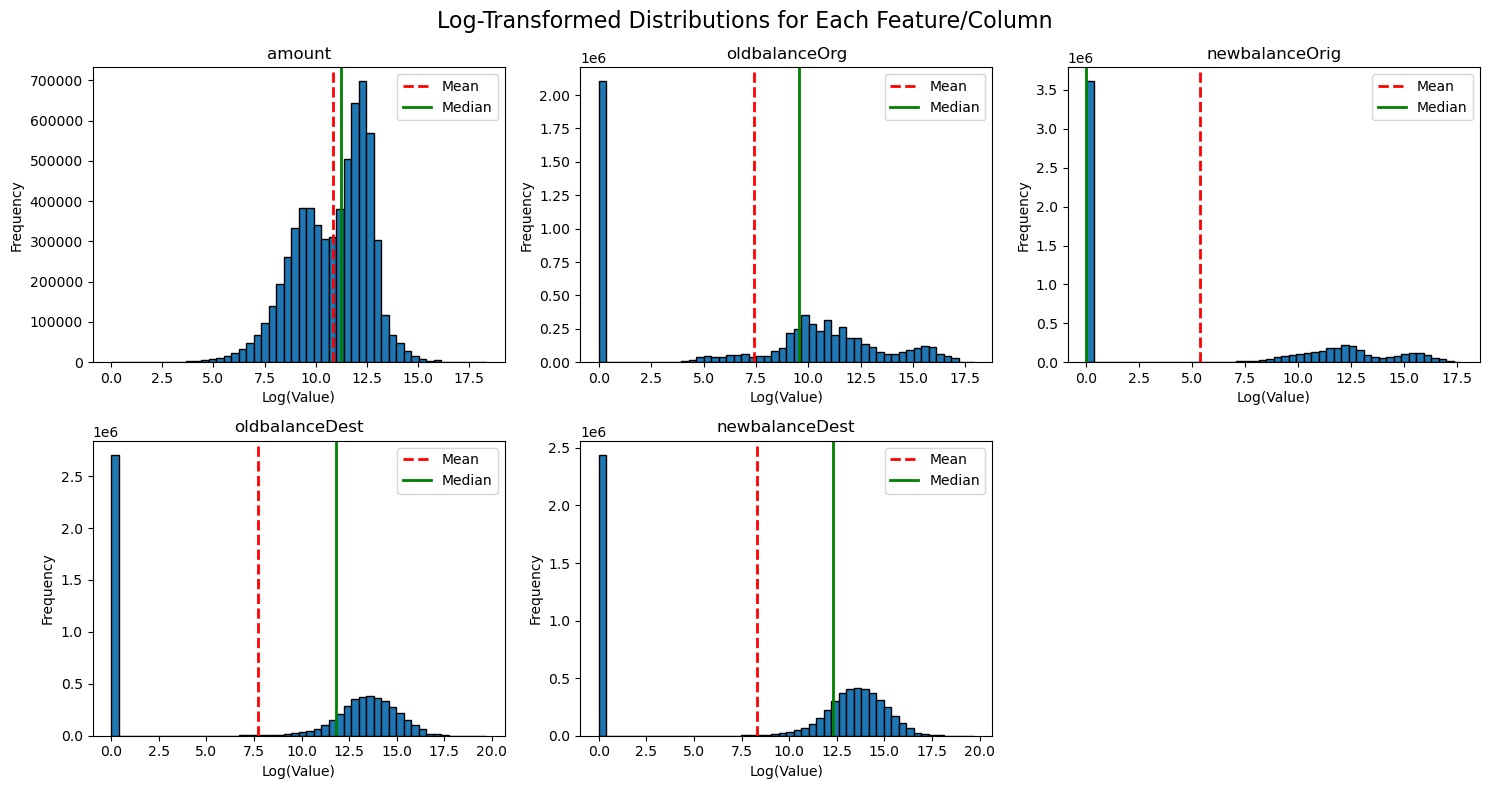

In [8]:
cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cols):
    data = np.log1p(df[col])
    
    # Histogram
    axes[i].hist(data, bins=50, edgecolor='black')
    
    # Mean & Median
    mean_val = data.mean()
    median_val = data.median()
    
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, label='Mean')
    axes[i].axvline(median_val, color='green', linestyle='-', linewidth=2, label='Median')
    
    # Labels
    axes[i].set_title(col)
    axes[i].set_xlabel('Log(Value)')
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

# Remove empty subplot
fig.delaxes(axes[5])

fig.suptitle("Log-Transformed Distributions for Each Feature/Column", fontsize=16)

plt.tight_layout()
plt.show()

<u>Insights:</u> Applying a log transformation helps better visualize the distribution and reveals the underlying pattern of the data.
- The `amount` column is the most balanced, with transactions spread around a clear middle range.
- The balance columns (`oldbalanceOrg`, `newbalanceOrig`, `oldbalanceDest`, `newbalanceDest`) show a large spike at zero, meaning many accounts have little to no balance.
- For the balance features, most of the actual values (non-zero) are spread out on the right side, showing a wide range of account balances.
- The mean is consistently lower than the median in the balance columns, which shows that the large number of zero values is pulling the average down.
- Compared to `amount`, the balance columns are more uneven and contain more extreme cases (especially many zero values).

#### Taking a closer look on outliers:

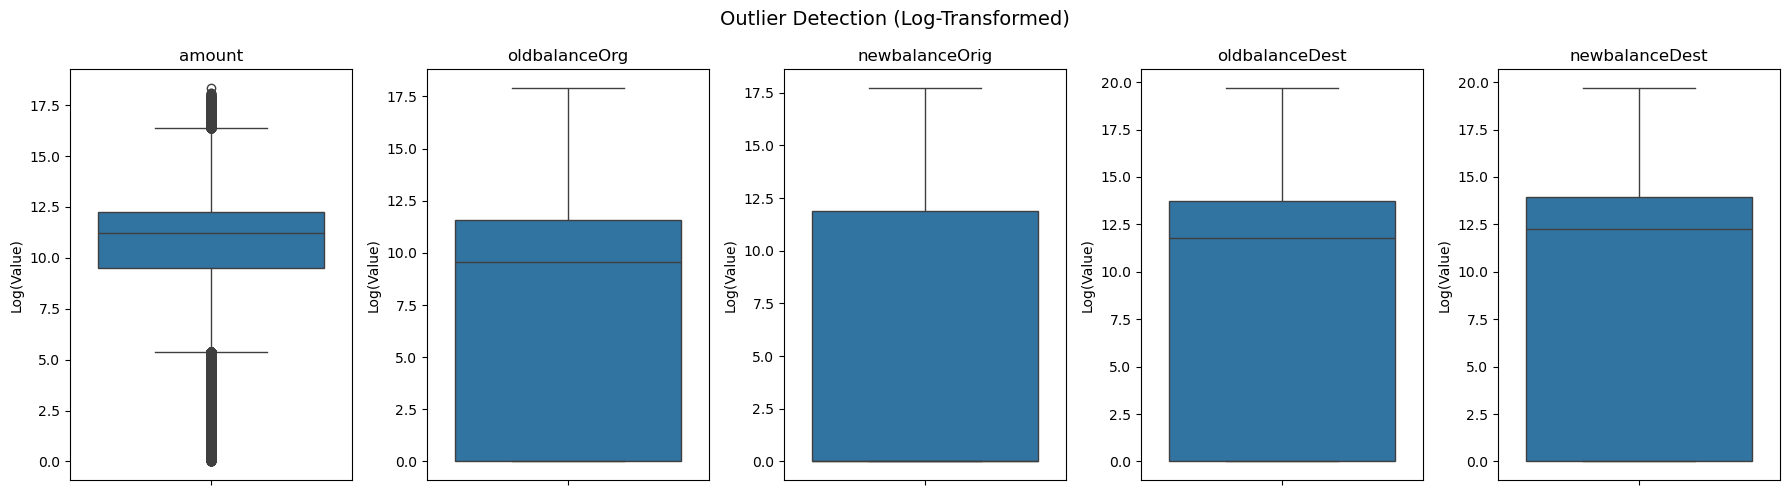

In [9]:
cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for i, col in enumerate(cols):
    data = np.log1p(df[col])
    
    sns.boxplot(y=data, ax=axes[i])
    
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Log(Value)')

plt.suptitle("Outlier Detection (Log-Transformed)", fontsize=14)

plt.tight_layout()
plt.show()

<u>Insights:</u>
- amount still has outliers, some transactions are unusually large/small (possible fraud signals)
- Sender balances (oldbalanceOrg, newbalanceOrig) jump a lot, some accounts get drained to near zero
- Receiver balances are also spread out, money flow is uneven, possibly funneled to certain accounts
- Log transform helped normalize the data, but extreme values still exist and are important to keep

#### type

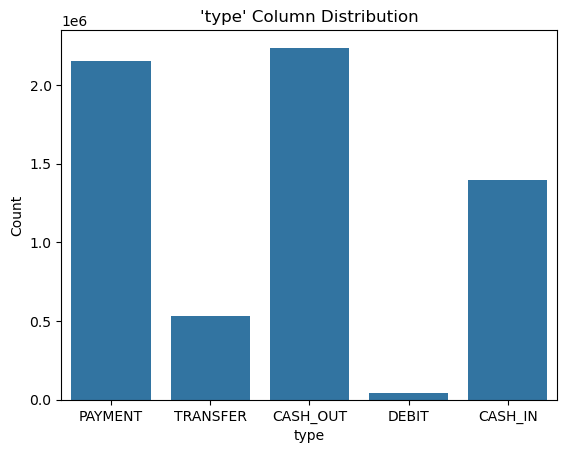

In [10]:
sns.countplot(x='type', data=df)

plt.title("'type' Column Distribution")
plt.xlabel("type")
plt.ylabel("Count")

plt.show()

<u>Insights:</u>

- CASH_OUT and PAYMENT happen the most — these are the most common transactions.
- CASH_IN also happens a lot, but not as much as CASH_OUT and PAYMENT.
- TRANSFER happens less often compared to the top ones.
- DEBIT is very rare in this dataset.
- Overall, most activity is focused on just a few transaction types.

#### isFraud & isFlaggedFraud

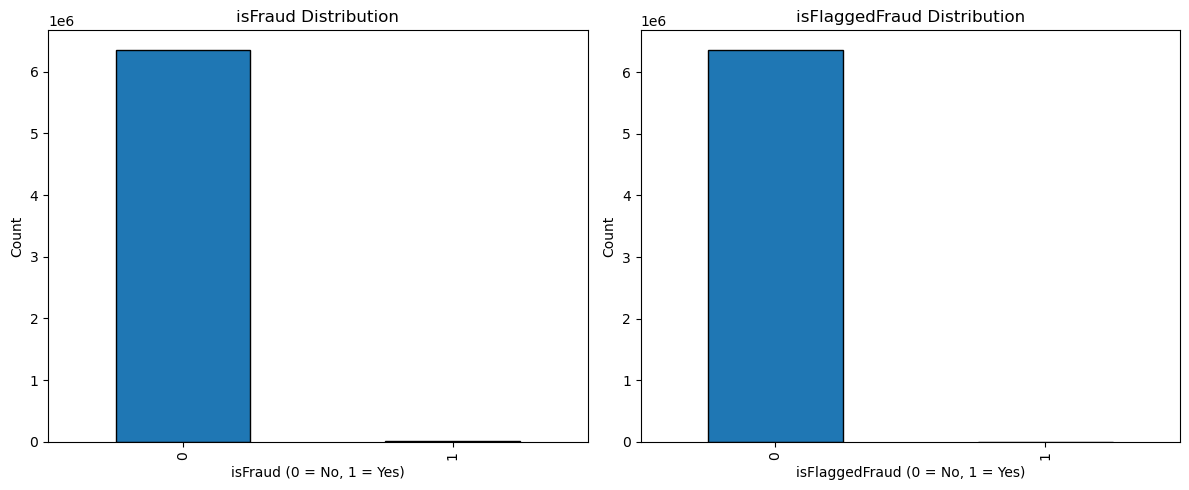

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# isFraud
df['isFraud'].value_counts().plot(
    kind='bar',
    ax=axes[0],
    edgecolor='black'
)
axes[0].set_title("isFraud Distribution")
axes[0].set_xlabel("isFraud (0 = No, 1 = Yes)")
axes[0].set_ylabel("Count")

# isFlaggedFraud
df['isFlaggedFraud'].value_counts().plot(
    kind='bar',
    ax=axes[1],
    edgecolor='black'
)
axes[1].set_title("isFlaggedFraud Distribution")
axes[1].set_xlabel("isFlaggedFraud (0 = No, 1 = Yes)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

<u>Insights:</u>

- Fraud cases are very rare compared to normal transactions.
- Flagged fraud cases are also very few.
- This shows that most transactions are not fraud.
- It also suggests that the system flags only a small number of transactions as fraud.

### <u>Bivariate Analysis</U>
In this part, I explore how two variables relate to each other, especially how different features connect to fraud. This helps me see patterns and relationships that might be useful later on.

#### amount vs isFraud
How much amounts are more likely to be fraud?

/var/folders/hj/vspbz7893wg2hk3mxnn5mvkc0000gn/T/ipykernel_9188/4179102825.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


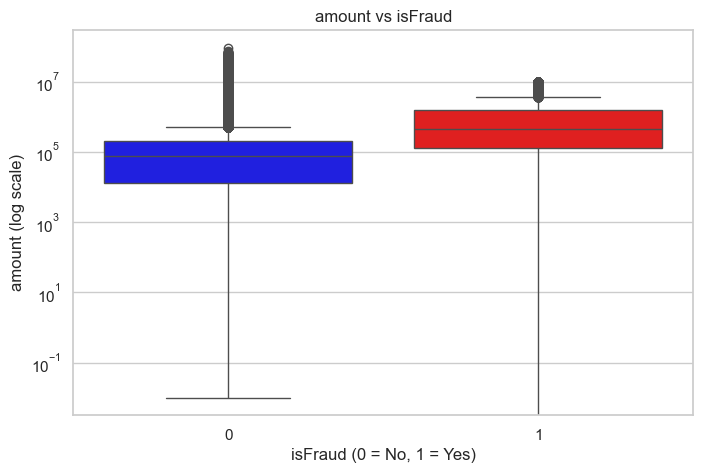

In [12]:
# Set style for better visuals
sns.set(style="whitegrid")

# Create figure
plt.figure(figsize=(8, 5))

# Boxplot
sns.boxplot(
    x='isFraud',
    y='amount', 
    data=df,
    palette={'0': 'blue', '1': 'red'}
)

# Apply log scale (important due to skewness)
plt.yscale('log')

# Titles and labels
plt.title('amount vs isFraud')
plt.xlabel('isFraud (0 = No, 1 = Yes)')
plt.ylabel('amount (log scale)')

# Show plot
plt.show()

<u>Insights:</u>
- Fraud transactions (red) generally have higher amounts compared to normal ones
- The data is super skewed, that’s why we used log scale to actually see the difference
- There are a lot of extreme values (outliers), especially on the non-fraud side
- Even though small transactions happen a lot, fraud is more likely in bigger money transfers

#### type vs isFraud
Which transaction types are more likely to be fraud?

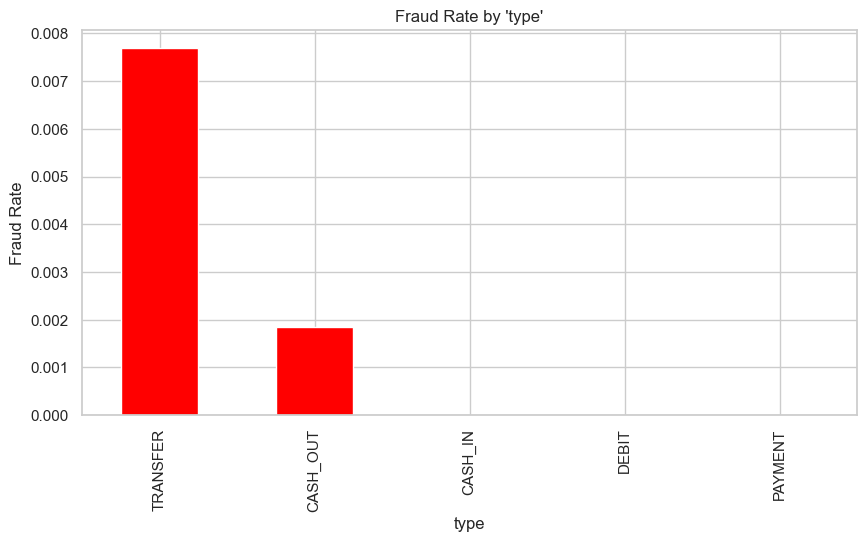

In [13]:
fraud_by_type = df.groupby('type')['isFraud'].mean().sort_values(ascending=False)

fraud_by_type.plot(kind='bar', figsize=(10,5), color='red')

plt.title("Fraud Rate by 'type'")
plt.xlabel("type")
plt.ylabel("Fraud Rate")

plt.show()

<u>Insights:</U>
- Fraud is not evenly distributed across transaction types.
- Most fraud appears to occur in TRANSFER and CASH_OUT transactions.
- Other transaction types like PAYMENT and CASH_IN show little to no fraud activity.
- This suggests that certain transaction types are much riskier and should be monitored more closely.


#### step (time) vs isFraud
Is there a specific time where fraud happens a lot?

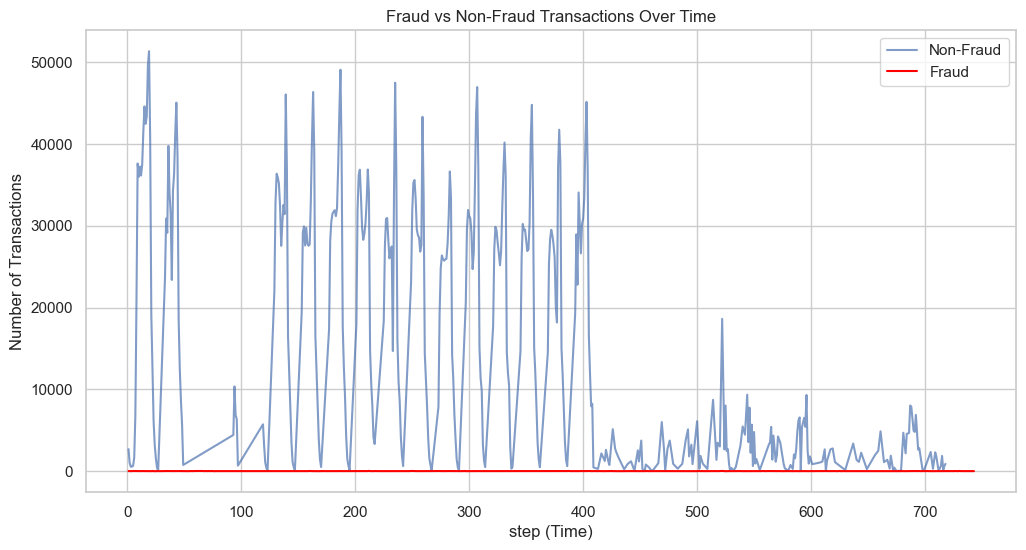

In [14]:
fraud_time = df[df['isFraud'] == 1].groupby('step').size()
nonfraud_time = df[df['isFraud'] == 0].groupby('step').size()

plt.figure(figsize=(12,6))

plt.plot(nonfraud_time, label='Non-Fraud', alpha=0.7)
plt.plot(fraud_time, label='Fraud', color='red')

plt.title("Fraud vs Non-Fraud Transactions Over Time")
plt.xlabel("step (Time)")
plt.ylabel("Number of Transactions")
plt.legend()

plt.show()

<u>Insights:</u>
- Most of the activity over time is coming from non-fraud transactions, fraud is barely visible because it’s so rare
- The transaction volume goes up and down a lot, but fraud doesn’t really follow those spikes clearly
- Even during peak transaction times, fraud stays very low, so it’s not tied directly to high activity periods
- This makes fraud harder to detect since it’s hidden within normal transactions
- Overall, looking at raw counts over time doesn’t tell us much about fraud, so using fraud rate is more helpful for spotting patterns


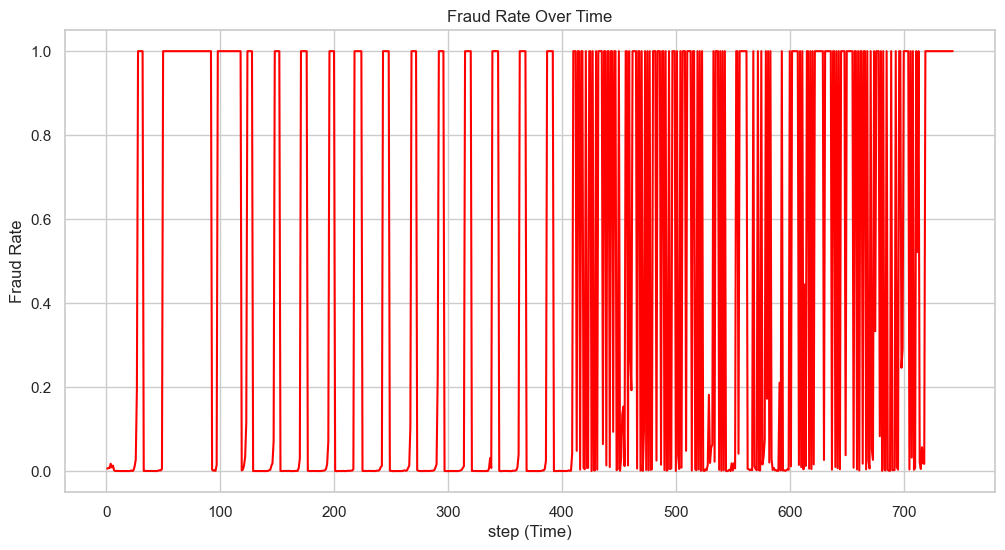

In [15]:
fraud_rate = df.groupby('step')['isFraud'].mean()

plt.figure(figsize=(12,6))
plt.plot(fraud_rate, color='red')

plt.title("Fraud Rate Over Time")
plt.xlabel("step (Time)")
plt.ylabel("Fraud Rate")

plt.show()

<u>Insights:</u>
- Looking at fraud rate over time gives a clearer picture compared to raw counts
- The spikes in fraud rate are mostly due to some time steps having very few transactions, where even 1 fraud can make the rate jump high
- There are more frequent spikes in later time steps, suggesting fraud may happen more often during those periods
- Overall, fraud doesn’t follow a smooth trend and seems to occur in bursts rather than evenly over time

### <u>Multivariate Analysis</u>
In this part, I look at how multiple variables work together and relate to fraud. This helps me spot deeper patterns that I wouldn’t see when analyzing just one or two variables at a time.

#### How Numerical Features Relate to Each Other:

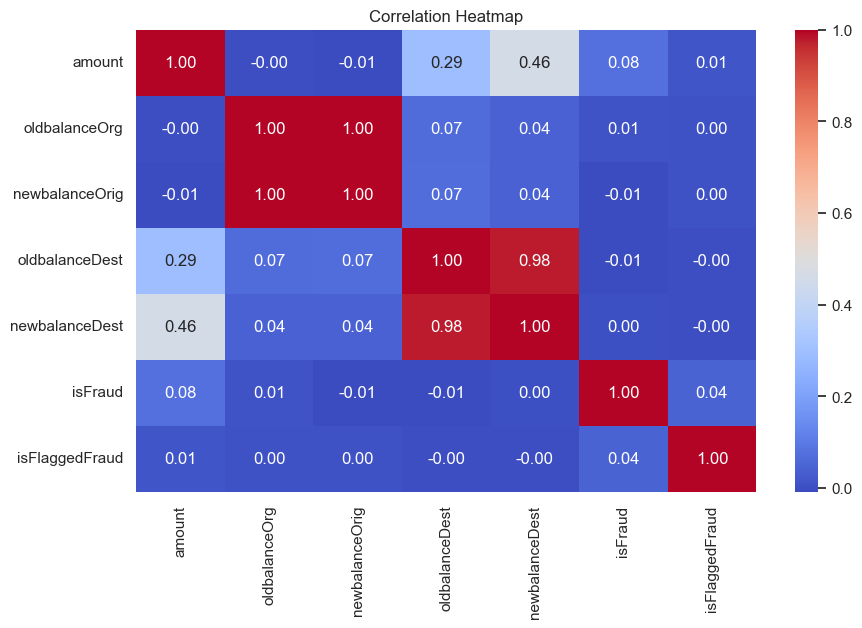

In [16]:
plt.figure(figsize=(10,6))

corr = df[['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

<u>Insights:</u>
- The origin balances (oldbalanceOrg and newbalanceOrig) are basically identical (correlation = 1.00), same with destination balances, kinda redundant info, so we might not need both.
- oldbalanceDest and newbalanceDest are also super highly related (0.98), which again hints at multicollinearity, something to clean up later.
- amount has some moderate relationship with destination balances (0.29–0.46), so bigger transactions tend to slightly affect destination accounts more.
- isFraud barely correlates with anything (all near 0), which means fraud isn’t obvious from just one feature. We’ll need combinations of features or models to detect it properly

#### How Transaction Type and Amount Relate to Fraud:

In [17]:
# Group by transaction type and fraud
grouped = df.groupby(['type', 'isFraud'])['amount'].agg(['count', 'mean', 'sum']).reset_index()

grouped

,type,isFraud,count,mean,sum
0,CASH_IN,0,1399284,1.689202e+05,2.363674e+11
1,CASH_OUT,0,2233384,1.739172e+05,3.884238e+11
2,CASH_OUT,1,4116,1.455103e+06,5.989202e+09
3,DEBIT,0,41432,5.483665e+03,2.271992e+08
4,PAYMENT,0,2151495,1.305760e+04,2.809337e+10
5,TRANSFER,0,528812,9.062290e+05,4.792248e+11
6,TRANSFER,1,4097,1.480892e+06,6.067213e+09


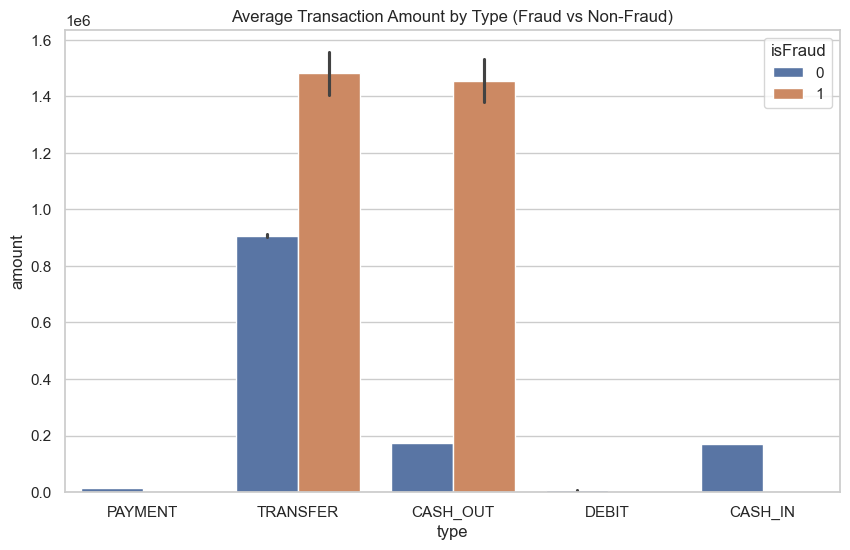

In [18]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x='type',
    y='amount',
    hue='isFraud',
    estimator='mean'
)

plt.title('Average Transaction Amount by Type (Fraud vs Non-Fraud)')
plt.show()

<u>Insights:</u>
- Fraud mostly happens in TRANSFER and CASH_OUT, and the amounts there are way higher compared to normal transactions
- For both TRANSFER and CASH_OUT, fraud transactions are significantly larger on average than non-fraud — big red flag behavior
- Other types like PAYMENT, DEBIT, and CASH_IN barely show any fraud, so they’re kinda low-risk compared to the others
- This makes transaction type + amount combo really important — not just how much, but what kind of transaction it is

#### How Log-Scaled Amount and Balances Relate to Fraud:

/var/folders/hj/vspbz7893wg2hk3mxnn5mvkc0000gn/T/ipykernel_9188/2219567514.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/hj/vspbz7893wg2hk3mxnn5mvkc0000gn/T/ipykernel_9188/2219567514.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/hj/vspbz7893wg2hk3mxnn5mvkc0000gn/T/ipykernel_9188/2219567514.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/hj/vspbz7893wg2hk3mxnn5mvkc0000gn/T/ipykernel_9188/2219567514.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and w

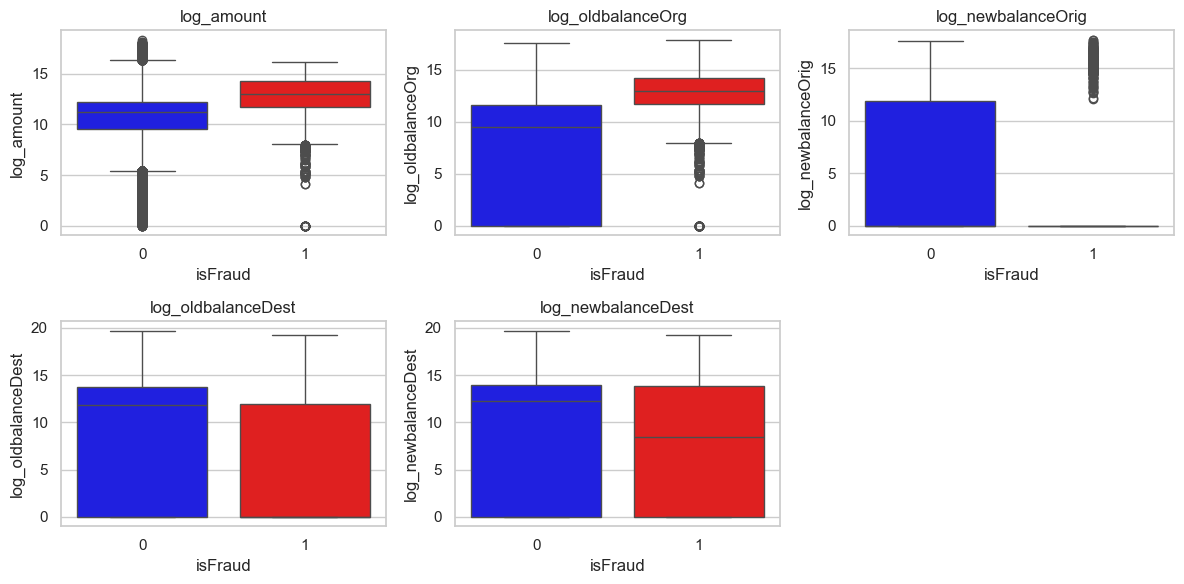

In [25]:
cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 
        'oldbalanceDest', 'newbalanceDest']

for col in cols:
    df[f'log_{col}'] = np.log1p(df[col])

plt.figure(figsize=(12,6))

log_cols = [f'log_{col}' for col in cols]

for i, col in enumerate(log_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(
        x='isFraud',
        y=col,
        data=df,
        palette={'0': 'blue', '1': 'red'}
    )
    plt.title(col)

plt.tight_layout()
plt.show()

<u>Insights:</u>
- Fraud transactions (1) generally have higher amounts compared to normal ones, even after log scaling
- Fraud cases tend to start with higher original balances, suggesting attackers target accounts with more money
- For fraud, the new balance of the sender often drops close to zero, which looks like money being drained
- Destination balances don’t show a super clear pattern, meaning fraud behavior is more obvious on the sender side than receiver side

#### Dropping columns: Which columns might not be useful?

The columns `nameOrig` and `nameDest` represent unique account identifiers. These do not provide meaningful patterns for analysis since they are mostly unique values.

### EDA Summary and Key Insights:
In this EDA, I explored the data from different angles to understand what separates fraud from normal transactions. I found that fraud usually involves higher amounts and is more common in specific transaction types like transfers and cash-outs. Balance-related features also showed unusual patterns, like accounts being drained or inconsistent changes.

Using log transformation helped make these patterns easier to see, especially with the highly skewed data. The correlation analysis also showed strong relationships between balance features, which could be useful for modeling.

Overall, these insights give a solid starting point for selecting features and building a model to detect fraudulent transactions.